## Introduction & Problem Statement

In this project, we aim to predict medical insurance charges based on personal attributes such as age, BMI, smoking status, and other factors.

The goal is to build a regression model (Linear Regression) that can estimate insurance costs and help understand which factors influence charges the most.

importing libraries


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


## Dataset Understanding

The dataset used is the Medical Cost Personal Dataset.

Features:
- age: Age of the person
- sex: Gender (male/female)
- bmi: Body Mass Index
- children: Number of dependents
- smoker: Smoking status (yes/no)
- region: Residential area
- charges: Medical insurance cost (target variable)

In [ ]:
df = pd.read_csv('C:\\Users\\HP\\Downloads\\archive (1)\\insurance.csv')


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

## Exploratory Data Analysis (EDA)

We analyze how different features affect insurance charges.

BMI VS CHARGES

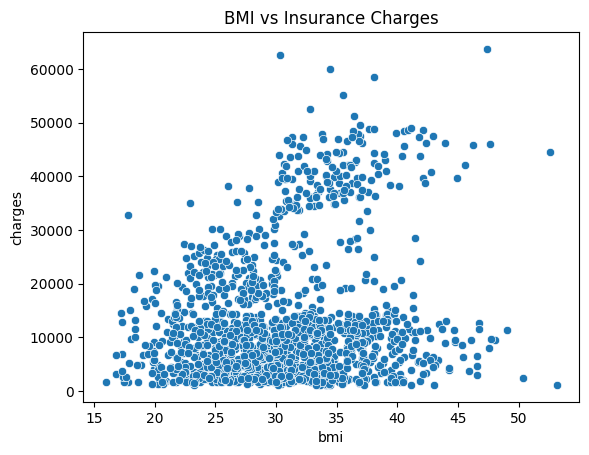

In [ ]:
sns.scatterplot(x="bmi", y="charges", data=df)
plt.title("BMI vs Insurance Charges")
plt.show()

AGE VS CHARGES

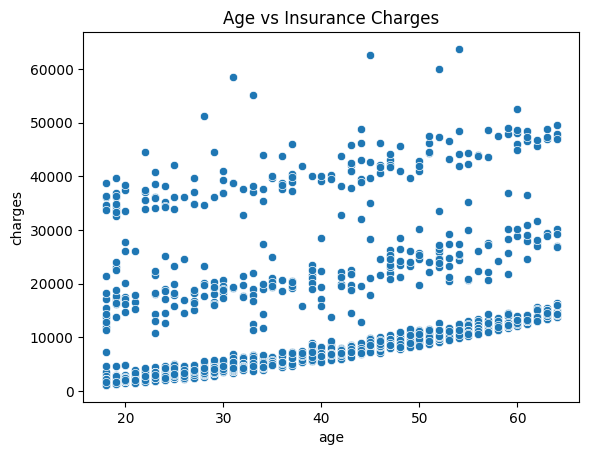

In [ ]:
sns.scatterplot(x="age", y="charges", data=df)
plt.title("Age vs Insurance Charges")
plt.show()

SMOKING IMPACT

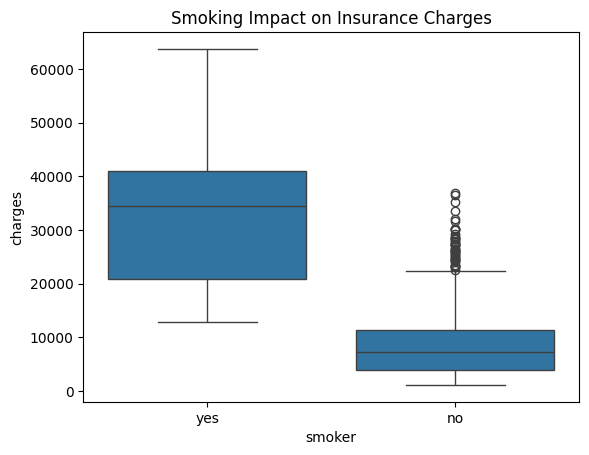

In [ ]:
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Smoking Impact on Insurance Charges")
plt.show()

In [ ]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 780.3 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/8.0 MB 961.3 kB/s eta 0:00:08
   ----- ---------------------------------- 1.0/8.0 MB 998.1 kB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.0 MB 998.1 kB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.0 MB 998.1 kB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.0 MB 835.1 kB/s eta 0:00:08
   ------ --------------------------------- 1.3/8.0 MB 835.1 kB/s eta 0:00:08
   ------- -------------------------------- 1.6/8.0 MB 741.4 kB/s eta 0:00:09
   --------- ------------------------------ 1.8/8.0 MB 780.6 kB/s eta 0:00:08
   ---------- ----------------------------- 2.1/8.0 MB 806.1 kB/s eta 0:00:08
   ----------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Model Training and Testing

We use Linear Regression to predict insurance charges.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("charges", axis=1)

y = df["charges"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
predictions = model.predict(X_test)

## Evaluation Metrics

We evaluate model performance using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [ ]:
mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 4181.194473753654


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("RMSE:", rmse)

RMSE: 5796.2846592762735


## Conclusion

- Smoking has the highest impact on insurance charges
- Older individuals tend to have higher charges
- BMI also positively correlates with charges
- The Linear Regression model provides a reasonable estimate of charges

This project demonstrates how machine learning can be used to predict costs and analyze key influencing factors.